# CNN with Batchnorm

- 3 convolutional blocks:
    - Conv2D → ReLU → MaxPooling
- Channel progression: 3 → 32 → 64 → 128

**Objective** <br/>
Evaluate whether adding Batch Normalization improves training stability and model performance.

**Changes from baseline** <br/>
- Added BatchNorm2d after each Conv2d layer
- Kept CNN architecture unchanged

**Hypothesis** <br/>
Batch Normalization will stabilize training, improve convergence, and lead to better generalization performance.

### 1. Import libraries

In [ ]:
import sys
import os
from pathlib import Path

# Find project root regardless of CWD (works in VS Code, Jupyter Lab, etc.)
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from src.data.dataloader import get_dataloaders
from src.models.cnn_batchnorm import BatchNormCNN
from src.training.trainer import train_one_epoch, validate_one_epoch


from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

os.chdir(ROOT)
print(Path.cwd())

### 2. Use Cuda else MPS

In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

MPS available: True
Using device: mps


### 3. Split Dataset 
- Use batchNorm model
- Use BCEWithLogitsLoss
- Use Adam optimizer

In [ ]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='data_new/splits/train.csv',
    val_csv='data_new/splits/val.csv',
    test_csv='data_new/splits/test.csv',
    image_dir='data_new/images/train',
    test_image_dir='data_new/images/test',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv("data_new/splits/train.csv")

num_melanoma = (train_df["label"] == 1).sum()  # CSV melanoma
num_nevus = (train_df["label"] == 0).sum()     # CSV nevus

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print("pos_weight:", pos_weight)

model = BatchNormCNN().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

pos_weight: tensor([6.0244], device='mps:0')


### 4. Train Model

In [ ]:
model_save_path = os.path.abspath("models/cnn_batchnorm_weighted.pth")
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
##########
train_f2s = []
val_f2s = []
##########

best_val_f2 = -1.0

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics["loss"])
    val_losses.append(val_metrics["loss"])
    train_accuracies.append(train_metrics["accuracy"])
    val_accuracies.append(val_metrics["accuracy"])
    ##########
    train_f2s.append(train_metrics["f2"])
    val_f2s.append(val_metrics["f2"])
    ##########

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Train Acc: {train_metrics['accuracy']:.4f}, Train F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}, Val F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics["f2"] > best_val_f2:
        best_val_f2 = val_metrics["f2"]
        torch.save(model.state_dict(), model_save_path)
        print("Saved best model at epoch", epoch + 1)

Epoch [1/20] | Train Loss: 3.6416, Train Acc: 0.6164, Train F2: 0.5434 | Val Loss: 0.8972, Val Acc: 0.5968, Val F2: 0.6095
Saved best model at epoch 1


Epoch [2/20] | Train Loss: 0.8806, Train Acc: 0.6003, Train F2: 0.6055 | Val Loss: 0.9782, Val Acc: 0.6087, Val F2: 0.6043


Epoch [3/20] | Train Loss: 0.8689, Train Acc: 0.5866, Train F2: 0.6087 | Val Loss: 0.9360, Val Acc: 0.6147, Val F2: 0.6166
Saved best model at epoch 3


Epoch [4/20] | Train Loss: 0.8590, Train Acc: 0.6022, Train F2: 0.6173 | Val Loss: 0.9262, Val Acc: 0.6181, Val F2: 0.6186
Saved best model at epoch 4


Epoch [5/20] | Train Loss: 0.8276, Train Acc: 0.6190, Train F2: 0.6199 | Val Loss: 0.9470, Val Acc: 0.7221, Val F2: 0.6391
Saved best model at epoch 5


...

Epoch [16/20] | Train Loss: 0.8131, Train Acc: 0.7507, Train F2: 0.6484 | Val Loss: 0.8679, Val Acc: 0.7809, Val F2: 0.6494


Epoch [17/20] | Train Loss: 0.7778, Train Acc: 0.7723, Train F2: 0.6580 | Val Loss: 0.9851, Val Acc: 0.7843, Val F2: 0.5647


Epoch [18/20] | Train Loss: 0.8082, Train Acc: 0.7602, Train F2: 0.6462 | Val Loss: 0.8688, Val Acc: 0.6590, Val F2: 0.6552
Saved best model at epoch 18


Epoch [19/20] | Train Loss: 0.7845, Train Acc: 0.7878, Train F2: 0.6690 | Val Loss: 0.8484, Val Acc: 0.7485, Val F2: 0.6367


Epoch [20/20] | Train Loss: 0.7929, Train Acc: 0.7871, Train F2: 0.6653 | Val Loss: 0.8074, Val Acc: 0.7647, Val F2: 0.6553
Saved best model at epoch 20


### 5. Plot Loss and Accuracy Curves

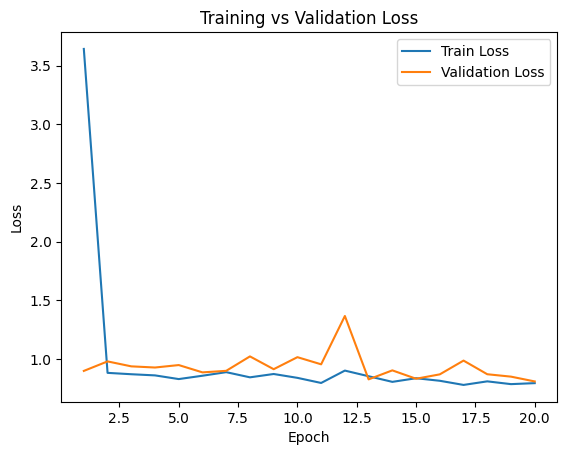

In [28]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

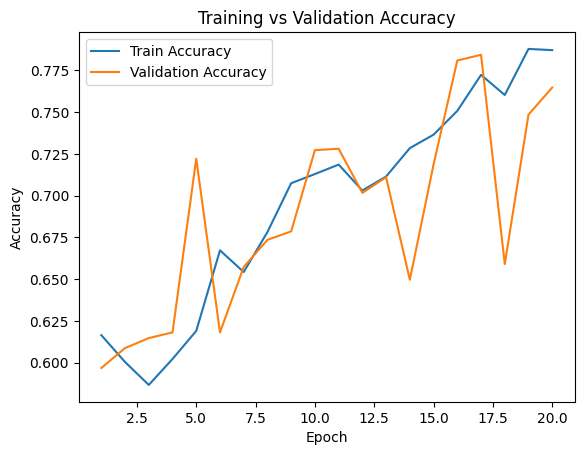

In [29]:
plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

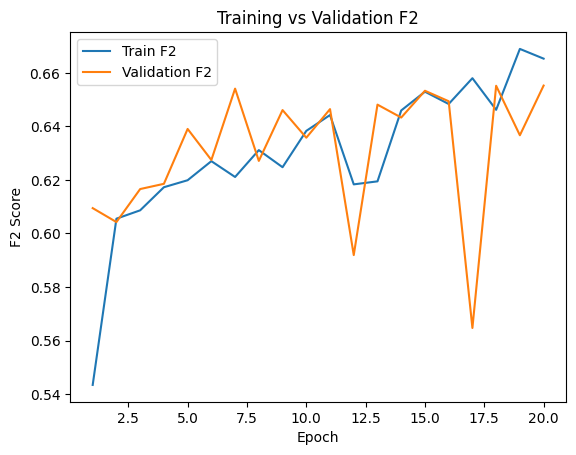

In [30]:
plt.figure()
plt.plot(epochs, train_f2s, label="Train F2")
plt.plot(epochs, val_f2s, label="Validation F2")

plt.xlabel("Epoch")
plt.ylabel("F2 Score")
plt.title("Training vs Validation F2")
plt.legend()
plt.show()

### 6. Evaluate model
[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

Precision → “When the model says YES, how often is it correct?” <br/>
Recall → “Out of all actual YES, how many did we catch?”

In [31]:
from sklearn.metrics import fbeta_score, precision_score, recall_score, balanced_accuracy_score
import numpy as np

model.eval()

val_labels = []
val_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)

        val_labels.extend(labels.numpy())
        val_probs.extend(probs.cpu().numpy())

thresholds = np.arange(0.05, 0.95, 0.05)

best_threshold = 0.5
best_f2 = -1

for threshold in thresholds:
    preds = [1 if p >= threshold else 0 for p in val_probs]
    f2 = fbeta_score(val_labels, preds, beta=2)

    print(
        f"Threshold={threshold:.2f} | "
        f"F2={f2:.4f} | "
        f"Precision={precision_score(val_labels, preds):.4f} | "
        f"Recall={recall_score(val_labels, preds):.4f} | "
        f"Balanced Acc={balanced_accuracy_score(val_labels, preds):.4f}"
    )

    if f2 > best_f2:
        best_f2 = f2
        best_threshold = threshold

print(f"\nBest threshold on validation set: {best_threshold:.2f}")


Threshold=0.05 | F2=0.5845 | Precision=0.2231 | Recall=0.9820 | Balanced Acc=0.7072
Threshold=0.10 | F2=0.6021 | Precision=0.2363 | Recall=0.9820 | Balanced Acc=0.7276
Threshold=0.15 | F2=0.6106 | Precision=0.2430 | Recall=0.9820 | Balanced Acc=0.7370
Threshold=0.20 | F2=0.6160 | Precision=0.2489 | Recall=0.9760 | Balanced Acc=0.7435
Threshold=0.25 | F2=0.6207 | Precision=0.2527 | Recall=0.9760 | Balanced Acc=0.7485
Threshold=0.30 | F2=0.6240 | Precision=0.2555 | Recall=0.9760 | Balanced Acc=0.7519
Threshold=0.35 | F2=0.6308 | Precision=0.2612 | Recall=0.9760 | Balanced Acc=0.7589
Threshold=0.40 | F2=0.6398 | Precision=0.2709 | Recall=0.9701 | Balanced Acc=0.7683
Threshold=0.45 | F2=0.6699 | Precision=0.3228 | Recall=0.9162 | Balanced Acc=0.7985
Threshold=0.50 | F2=0.6546 | Precision=0.3575 | Recall=0.8263 | Balanced Acc=0.7899
Threshold=0.55 | F2=0.6369 | Precision=0.3860 | Recall=0.7605 | Balanced Acc=0.7798
Threshold=0.60 | F2=0.6171 | Precision=0.4179 | Recall=0.7006 | Balanced Acc

#### 7. Use best threshold

In [36]:
model.eval()

all_labels = []
all_probs = []
all_preds = []

threshold = best_threshold

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)                      # raw logits
        probs = torch.sigmoid(outputs).squeeze(1)    # probabilities
        preds = (probs >= threshold).long()            # binary predictions

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [37]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

print(classification_report(all_labels, all_preds, digits=4))

Confusion Matrix:
[[688 318]
 [ 13 154]]
              precision    recall  f1-score   support

           0     0.9815    0.6839    0.8061      1006
           1     0.3263    0.9222    0.4820       167

    accuracy                         0.7178      1173
   macro avg     0.6539    0.8030    0.6440      1173
weighted avg     0.8882    0.7178    0.7600      1173



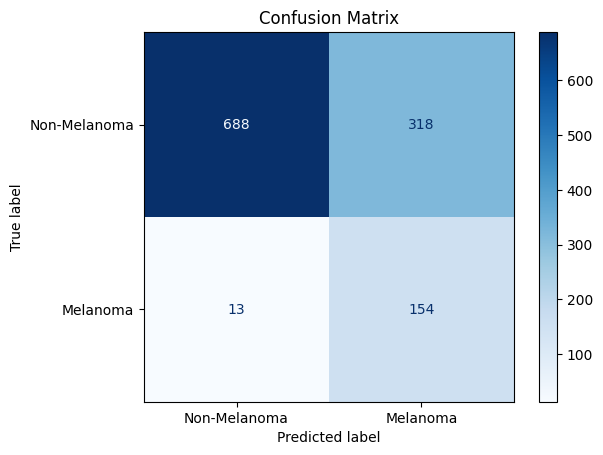

In [38]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Melanoma", "Melanoma"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()